In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_aws.chat_models import ChatBedrock
import boto3
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
from botocore.credentials import RefreshableCredentials
from botocore.session import get_session

ROLE_ARN = os.getenv('ROLE_ARN')
REGION = os.getenv('AWS_REGION')

ROLE_SESSION_NAME = "bedrock-session"


sts = boto3.client("sts")
 
response = sts.assume_role(
    RoleArn=ROLE_ARN,
    RoleSessionName="bedrock-session"
)
 
creds = response["Credentials"]
 
session = boto3.Session(
    aws_access_key_id=creds["AccessKeyId"],
    aws_secret_access_key=creds["SecretAccessKey"],
    aws_session_token=creds["SessionToken"],
    region_name=REGION
)

bedrock_client = session.client(
    service_name="bedrock-runtime",
    region_name=REGION
)

In [4]:
provider = os.getenv("PROVIDER")
model_id = os.getenv("MODEL_ID")
model_kwargs = {
    "max_tokens":1000,
    "top_p": 0.9,
}

model = ChatBedrock(
        client=bedrock_client,
        provider=provider,
        model_id=model_id,  
        model_kwargs=model_kwargs,
        streaming=False
    )

In [5]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', gt=0, lt=10)

In [6]:
class EssayState(TypedDict, total=False):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [7]:
structured_model = model.with_structured_output(EvaluationSchema)

def eval_lang(state: EssayState):
    essay = state['essay']

    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}"

    response = structured_model.invoke(prompt)

    return {'language_feedback': response.feedback, 'individual_scores': [response.score]}

def eval_analysis(state: EssayState):
    essay = state['essay']

    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {essay}"

    response = structured_model.invoke(prompt)

    return {'analysis_feedback': response.feedback, 'individual_scores': [response.score]}

def eval_thought(state: EssayState):
    essay = state['essay']

    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}"

    response = structured_model.invoke(prompt)

    return {'clarity_feedback': response.feedback, 'individual_scores': [response.score]}

def final_eval(state: EssayState):

    prompt = f"Based on following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']} \n depth of analysis - {state['analysis_feedback']} \n clarity of thought - {state['clarity_feedback']}"

    response = model.invoke(prompt).content

    # avg score
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': response, 'avg_score': avg_score}

In [8]:
graph = StateGraph(EssayState)

# nodes
graph.add_node('eval_lang', eval_lang)
graph.add_node('eval_analysis', eval_analysis)
graph.add_node('eval_thought', eval_thought)
graph.add_node('final_eval', final_eval)

# edges
graph.add_edge(START, 'eval_lang')
graph.add_edge(START, 'eval_analysis')
graph.add_edge(START, 'eval_thought')

graph.add_edge('eval_lang', 'final_eval')
graph.add_edge('eval_analysis', 'final_eval')
graph.add_edge('eval_thought', 'final_eval')

graph.add_edge('final_eval', END)

# compile graph
workflow = graph.compile()

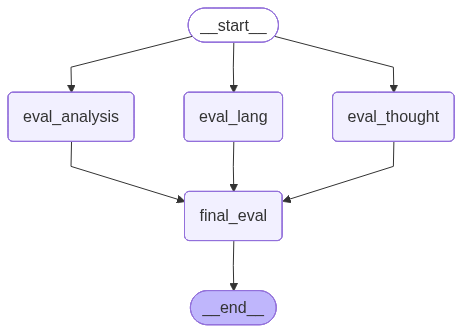

In [9]:
workflow

In [10]:
initial_state = {'essay': """
# Machine Learning

Machine Learning is a branch of Artificial Intelligence (AI) that enables computers to learn from data and improve their performance without being explicitly programmed. Instead of following fixed instructions, machine learning systems identify patterns in data and make decisions or predictions based on those patterns.

Machine learning has become one of the most important technologies in the modern world. It is used in many applications such as recommendation systems, voice assistants, self-driving cars, fraud detection, medical diagnosis, and image recognition. Popular platforms like Netflix, YouTube, and Amazon use machine learning algorithms to recommend content and products to users based on their preferences and behavior.

There are three major types of machine learning: supervised learning, unsupervised learning, and reinforcement learning. In supervised learning, models are trained using labeled data where the correct output is already known. In unsupervised learning, the system identifies hidden patterns or relationships in unlabeled data. Reinforcement learning involves learning through rewards and penalties by interacting with an environment.

The machine learning process generally involves collecting data, cleaning and preparing it, selecting a suitable model, training the model, testing its performance, and finally deploying it for real-world use. Common programming languages used in machine learning include Python and R, while popular libraries include TensorFlow, PyTorch, and Scikit-learn.

Machine learning offers many advantages. It can automate repetitive tasks, improve accuracy, process large amounts of data quickly, and help businesses make better decisions. However, it also has challenges such as data privacy concerns, bias in algorithms, and the need for large amounts of quality data.

In conclusion, machine learning is transforming industries and changing the way humans interact with technology. As data continues to grow rapidly, machine learning will play an even bigger role in shaping the future. Understanding machine learning is becoming increasingly important for students, researchers, and professionals in the digital age.
"""}

final_state = workflow.invoke(initial_state)

final_state

{'essay': '\n# Machine Learning\n\nMachine Learning is a branch of Artificial Intelligence (AI) that enables computers to learn from data and improve their performance without being explicitly programmed. Instead of following fixed instructions, machine learning systems identify patterns in data and make decisions or predictions based on those patterns.\n\nMachine learning has become one of the most important technologies in the modern world. It is used in many applications such as recommendation systems, voice assistants, self-driving cars, fraud detection, medical diagnosis, and image recognition. Popular platforms like Netflix, YouTube, and Amazon use machine learning algorithms to recommend content and products to users based on their preferences and behavior.\n\nThere are three major types of machine learning: supervised learning, unsupervised learning, and reinforcement learning. In supervised learning, models are trained using labeled data where the correct output is already kno